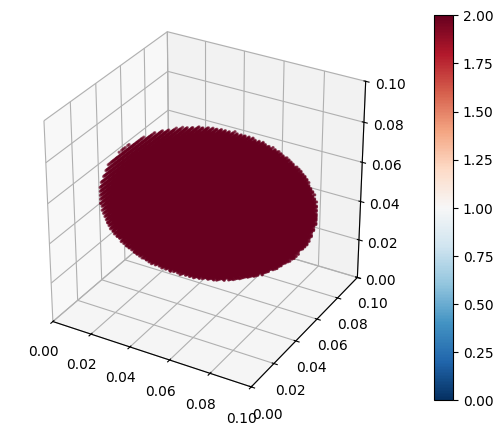

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

# --- domínio ---
a = 0.05
b = 0.04
c = 0.03

Nx = Ny = Nz = 50
dx = dy = dz = 2e-3
cx, cy, cz = Nx // 2, Ny // 2, Nz // 2
L = Nx * dx # dimensao do grid

# condição CFL para estabilidade
dt = 0.99 / (vp * np.sqrt(
    (1/dx**2) + (1/dy**2) + (1/dz**2)
))
Nt = 1000
T = Nt * dt

# define os grids - desenha a célula de Yee 3D
grid_x_base = np.linspace(0, L, Nx + 1)
grid_y_base = np.linspace(0, L, Ny + 1)
grid_z_base = np.linspace(0, L, Nz + 1)

grid_x_Ex = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Ex = np.linspace(0, L, Ny + 1)
grid_z_Ex = np.linspace(0, L, Nz + 1)

grid_x_Ey = np.linspace(0, L, Nx + 1)
grid_y_Ey = np.linspace(dy/2, L - dy/2, Ny)
grid_z_Ey = np.linspace(0, L, Nz + 1)

grid_x_Ez = np.linspace(0, L, Nx + 1)
grid_y_Ez = np.linspace(0, L, Ny + 1)
grid_z_Ez = np.linspace(dz/2, L - dz/2, Nz)

grid_x_Hx = np.linspace(0, L, Nx + 1)
grid_y_Hx = np.linspace(dy/2, L - dy/2, Ny)
grid_z_Hx = np.linspace(dz/2, L - dz/2, Nz)

grid_x_Hy = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Hy = np.linspace(0, L, Ny + 1)
grid_z_Hy = np.linspace(dz/2, L - dz/2, Nz)

grid_x_Hz = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Hz = np.linspace(dy/2, L - dy/2, Ny)
grid_z_Hz = np.linspace(0, L, Nz + 1)

# ponta de prova para coletar pontos para a FFT no centro da cavidade
probe = []
pcx, pcy, pcz = cx + 10, cy + 10, cz + 10

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(10, Nt - 2, 3, dtype=int)
# n_snapshots = range(Nt-1)
# n_snapshots = [Nt // 3, Nt//2, 2 * (Nt // 3)]
n_snapshots = [10, 20, 30, 40, 50, 60, 70]
Ez_snapshots = []

Ex = Ex_next = np.zeros((grid_x_Ex.shape[0], grid_y_Ex.shape[0],  grid_z_Ex.shape[0]))
Ey = Ey_next = np.zeros((grid_x_Ey.shape[0], grid_y_Ey.shape[0],  grid_z_Ey.shape[0]))
Ez = Ez_next = np.zeros((grid_x_Ez.shape[0], grid_y_Ez.shape[0],  grid_z_Ez.shape[0]))
Hx = Hx_next = np.zeros((grid_x_Hx.shape[0], grid_y_Hx.shape[0],  grid_z_Hx.shape[0]))
Hy = Hy_next = np.zeros((grid_x_Hy.shape[0], grid_y_Hy.shape[0],  grid_z_Hy.shape[0]))
Hz = Hz_next = np.zeros((grid_x_Hz.shape[0], grid_y_Hz.shape[0],  grid_z_Hz.shape[0]))

# prepara para os plots 3D
X, Y, Z = np.meshgrid(grid_x_base, grid_y_base, grid_z_base, indexing='ij')
mask = (X.flatten() - cx * dx)**2 / a**2 + (Y.flatten() - cy * dy)**2 / b**2 + (Z.flatten() - cz * dz)**2 / c**2 <= 1

# Example radial field (decaying)
F = np.repeat(2, X.flatten().shape) 

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    X.flatten()[mask],
    Y.flatten()[mask],
    Z.flatten()[mask],
    c=F.flatten()[mask],
    cmap='RdBu_r',
    vmin=0,vmax=2,
    s=2,
)

plt.colorbar(sc)
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.set_box_aspect([1,1,1])

plt.show()

In [51]:
X, Y, Z = np.meshgrid(grid_x_Ez, grid_y_Ez, grid_z_Ez, indexing='ij')
mask = (X - cx * dx)**2 / a**2 + (Y - cy * dy)**2 / b**2 + (Z - cz * dz)**2 / c**2 <= 1

for n in range(Nt-1):
    # --- fonte (pulso gaussiano no tempo) ---
    t0 = 50
    spread = 15
    source_gaussiano = np.exp(-((n - t0)**2) / spread**2)

    # --- fonte (senoidal no tempo) ---
    frequency = 1e9  # 1 GHz
    source_senoidal = np.sin(2 * np.pi * frequency * n * dt)

    Ez[cx, cy, cz] += source_gaussiano

    # --- Update H fields ---
    # Hx
    Hx_next[:, :, :] = Hx[:, :, :] - (dt/mu)*(
        (Ez[:, 1:, :] - Ez[:, :-1, :])/dy -
        (Ey[:, :, 1:] - Ey[:, :, :-1])/dz
    )

    # Hy
    Hy_next[:, :, :] = Hy[:, :, :] - (dt/mu)*(
        (Ex[:, :, 1:] - Ex[:, :, :-1])/dz -
        (Ez[1:, :, :] - Ez[:-1, :, :])/dx
    )

    # Hz
    Hz_next[:, :, :] = Hz[:, :, :] - (dt/mu)*(
        (Ey[1:, :, :] - Ey[:-1, :, :])/dx -
        (Ex[:, 1:, :] - Ex[:, :-1, :])/dy
    )

    # --- Update E fields ---
    # Ex
    Ex_next[:, 1:-1, 1:-1] = Ex[:, 1:-1, 1:-1] + (dt/eps)*(
        (Hz_next[:, 1:, 1:-1] - Hz_next[:, :-1, 1:-1])/dy -
        (Hy_next[:, 1:-1, 1:] - Hy_next[:, 1:-1, :-1])/dz
    )

    # Ey
    Ey_next[1:-1, :, 1:-1] = Ey[1:-1, :, 1:-1] + (dt/eps)*(
        (Hx_next[1:-1, :, 1:] - Hx_next[1:-1, :, :-1])/dz -
        (Hz_next[1:, :, 1:-1] - Hz_next[:-1, :, 1:-1])/dx
    )

    # Ez
    Ez_next[1:-1, 1:-1, :] = Ez[1:-1, 1:-1, :] + (dt/eps)*(
        (Hy_next[1:, 1:-1, :] - Hy_next[:-1, 1:-1, :])/dx -
        (Hx_next[1:-1, 1:, :] - Hx_next[1:-1, :-1, :])/dy
    )

    # zero nas extremidades e para fora da cavidade (condição de contorno)
    Ez_next[~mask] = 0

    # salva o valor no centro para a FFT
    probe.append(Ez_next[pcx, pcy, pcz])

    # atualiza os campos para o próximo passo
    Ex, Ex_next = Ex_next, Ex
    Ey, Ey_next = Ey_next, Ey
    Ez, Ez_next = Ez_next, Ez

    Hx, Hx_next = Hx_next, Hx
    Hy, Hy_next = Hy_next, Hy
    Hz, Hz_next = Hz_next, Hz

    # salva para os snapshots
    if n in n_snapshots:
        Ez_snapshots.append(Ez.copy())



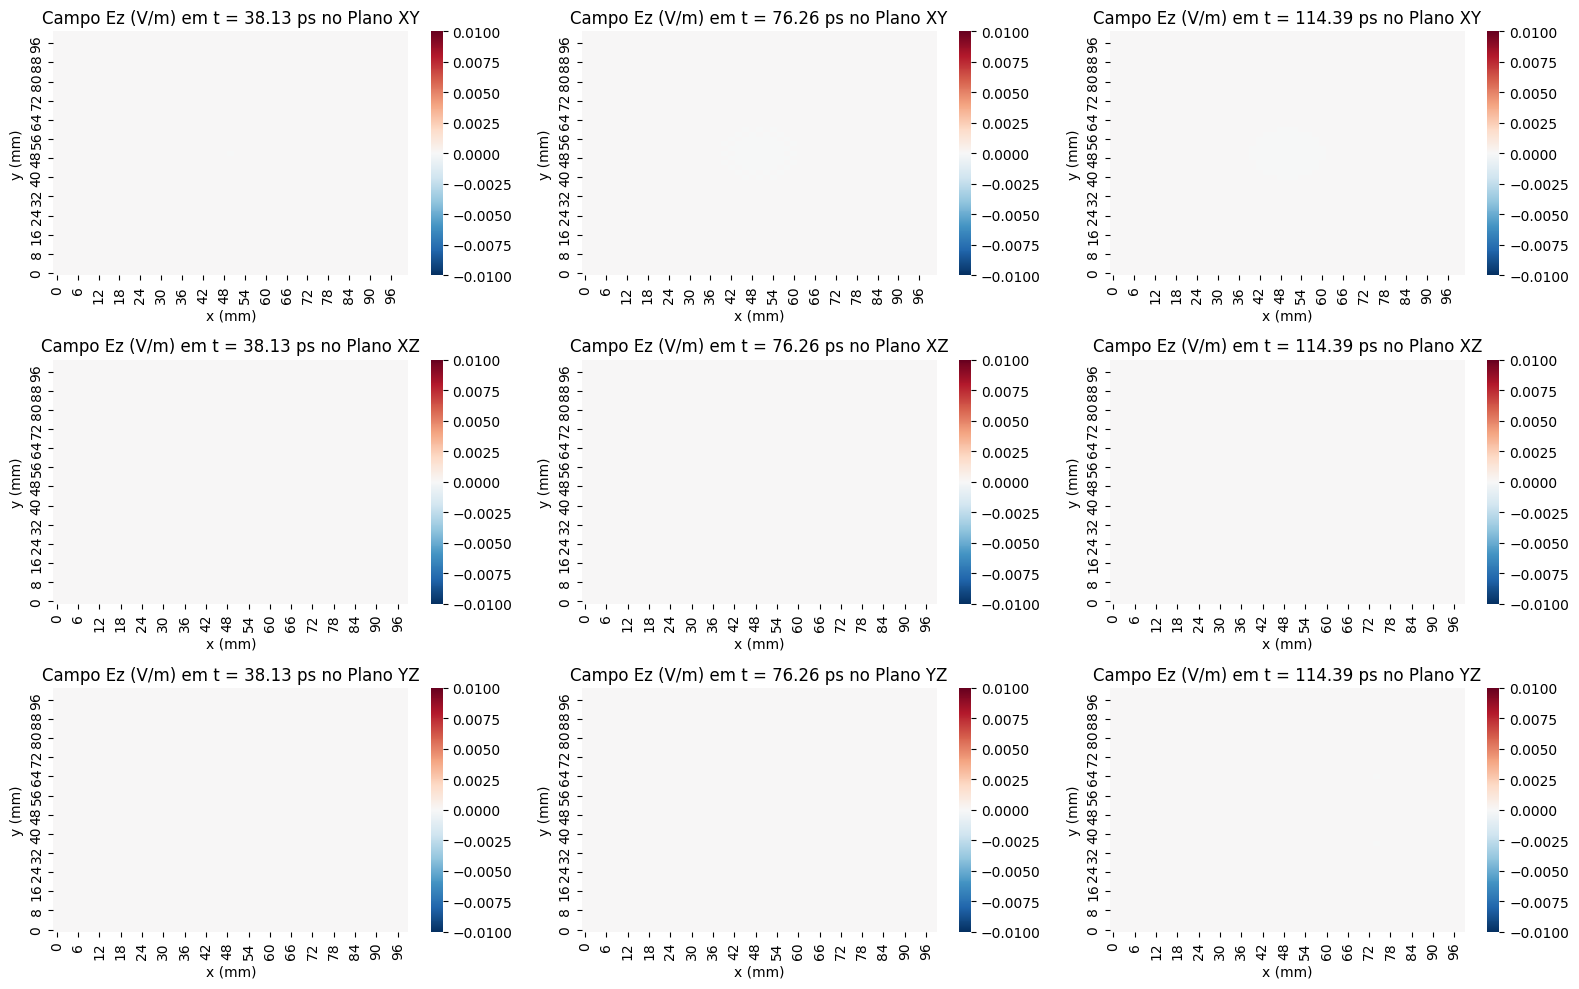

In [52]:
# Example radial field (decaying)
# prepara para os plots 3D
X, Y, Z = np.meshgrid(grid_x_Ez, grid_y_Ez, grid_z_Ez, indexing='ij')
mask = (X.flatten() - cx * dx)**2 / a**2 + (Y.flatten() - cy * dy)**2 / b**2 + (Z.flatten() - cz * dz)**2 / c**2 <= 1

# fixa no centro, a evolucao de Ez no eixo Z ao longo do tempo
xy_snaps = []
xz_snaps = []
yz_snaps = []
dist_from_center = 10 * dx # 20 mm
idx_from_center = int(dist_from_center / dx)

for n in range(len(n_snapshots)):
    F = Ez_snapshots[n]
    xy_snaps.append(F[:, :, cz + idx_from_center])
    xz_snaps.append(F[:, cy + idx_from_center, :])
    yz_snaps.append(F[cx + idx_from_center, :, :])

fig, axes = plt.subplots(3,3, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    idx = i % 3
    target_arr = []
    label = ""

    if i < 3: 
        target_arr = xy_snaps
        label = "Plano XY"
    if 3 <= i < 6: 
        target_arr = xz_snaps
        label = "Plano XZ"
    if 6 <= i < 9: 
        target_arr = yz_snaps
        label = "Plano YZ"

    sns.heatmap(target_arr[idx], ax=ax, annot=False, cmap='RdBu_r',vmin=-0.01,vmax=0.01,center=0)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Campo Ez (V/m) em t = {n_snapshots[idx]*dt*1e12:.2f} ps no {label}")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1000:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1000:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [53]:
Nt * dt

np.float64(3.813149738928423e-09)

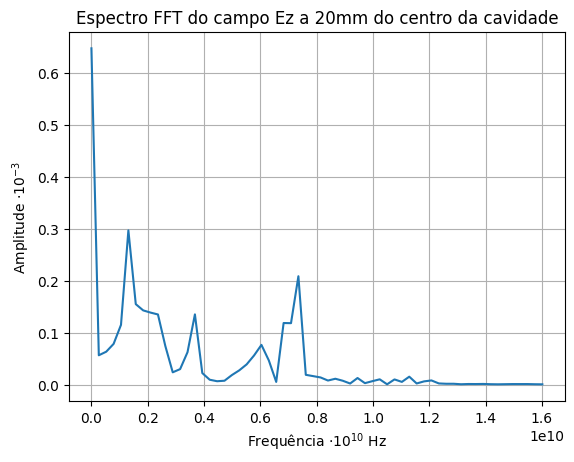

In [54]:
# 2. Compute the FFT
yf = fft(probe)
xf = fftfreq(len(probe), dt)

# 3. Plot the results (Positive frequencies only)
plt.plot(xf[:len(probe)//16], 1e3 * 2.0/len(probe) * np.abs(yf[:len(probe)//16]))
plt.title("Espectro FFT do campo Ez a 20mm do centro da cavidade")
plt.xlabel(r"Frequência $\cdot 10^{10}$ Hz")
plt.ylabel(r"Amplitude $\cdot 10^{-3}$")
plt.grid()
plt.show()

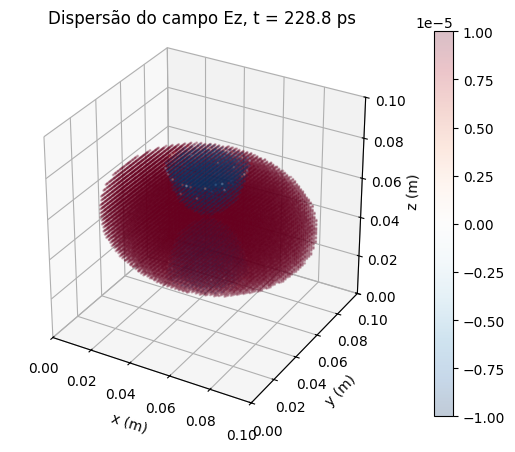

In [99]:
# prepara para os plots 3D
X, Y, Z = np.meshgrid(grid_x_Ez, grid_y_Ez, grid_z_Ez, indexing='ij')
mask = (X.flatten() - cx * dx)**2 / a**2 + (Y.flatten() - cy * dy)**2 / b**2 + (Z.flatten() - cz * dz)**2 / c**2 <= 1

# Example radial field (decaying)
snap_idx = 5
F = Ez_snapshots[snap_idx]

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    X.flatten()[mask],
    Y.flatten()[mask],
    Z.flatten()[mask],
    c=F.flatten()[mask],
    cmap='RdBu_r',
    vmin=-1e-5, vmax=1e-5,
    s=1,
    alpha=0.25
)

plt.colorbar(sc)
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.set_box_aspect([1,1,1])
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title(f"Dispersão do campo Ez, t = {n_snapshots[snap_idx] * dt * 1e12:.1f} ps")

plt.show()